<a href="https://colab.research.google.com/github/JenniferF1235/qj-s25/blob/main/IS474__CLV_CLV2_2__Jennifer_Feng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Start-Problem (Biz Models & Network Effects)** — This asks for short answers. No more than a sentence or two is needed for each specific example.


*   A.       (8 points) Consider first a platform’s monetization
strategy. Provide your two best examples of how firms have used pricing to increase network effects. Then, provide your two best examples of how pricing has decreased or harmed network effects. These can be intentional or unintentional. The latter, of course, is likely to be unintentional.
*   B.       (8 points) Consider second the platform’s architecture. Provide your two best examples of how firms have used architecture to increase network effects. Then, provide your two best examples of how architecture has decreased or harmed network effects.

*   C.      (4 points) Do both tasks above first without any AI.  Then repeat using AI.  Comment on the differences between the two answers.  What did you miss? What did the AI miss?


Grading on parts A & B is based on the best answer provided by you and the AI together. Grading on part C is based on clearly identifying either what you learned or how you beat the AI.

## TODO (Student Answer):

# **Pset1: CLV vs CLV2 in a Two-Sided Market (Synthetic Groupon-like Data)**

You are given a synthetic dataset of a two-sided platform (Consumers ↔ Merchants) across multiple markets over time.
Your goal is to estimate **Customer Lifetime Value (CLV)** and **CLV2** (CLV **with network effects**) and then use your model to recommend how the platform should spend **$100,000** to grow most effectively.
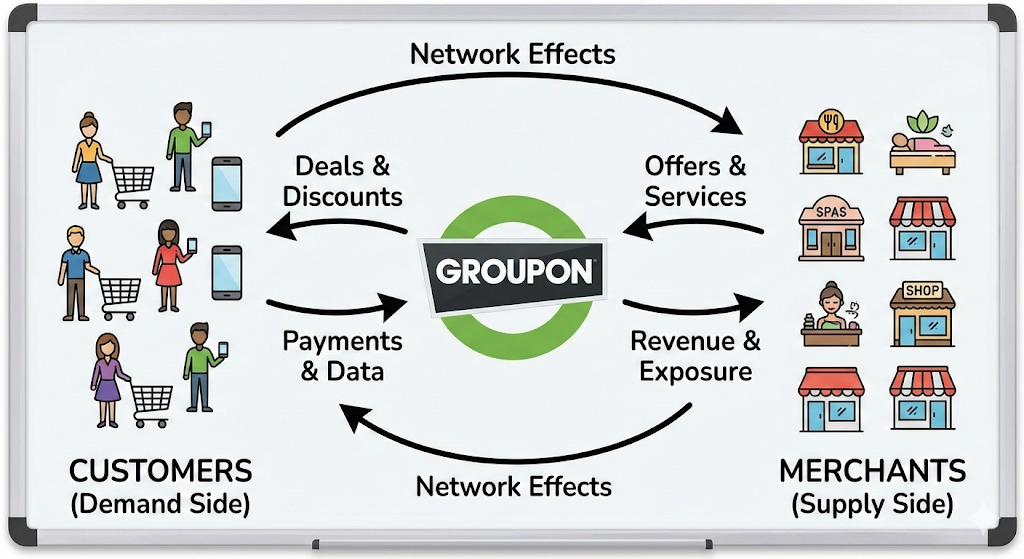
## What you will learn:
By the end, you should be able to:

1. Explain what a **two-sided platform** is and why **network effects** matter.
2. Estimate **cross-side network effects** from panel data using simple regressions.
3. Compute:
   - **CLV** (ignoring network effects)
   - **CLV2** (including network effects / feedback loops)
4. Use your model to evaluate growth levers:
   - Marketing via **CAC** (customer acquisition cost)
   - **Discounts**
   - **Network design** (strengthening network effects)
   - **Reducing churn** (improving retention / reducing leakage)

## ***Where you will write code vs answers***
Throughout the notebook you will see:

- `# TODO (STUDENT):` → you should write Python code
- `TODO (STUDENT ANSWER):` → you should write your interpretation

### You are encouraged to use AI to generate the code


#**0) Load the dataset**

In [2]:
import pandas as pd
import numpy as np
from google.colab import drive
# Method 1: upload groupon_synth_panel_data.csv via the file sidebar(need to re-upload once your session expired)
# DATA_PATH = "groupon_synth_panel_data.csv"

# Method 2: Mount Google Drive
drive.mount('/content/drive')
# Put your CSV in: MyDrive/IS474/ (or any folder you like)
DATA_PATH = "/content/drive/MyDrive/groupon_synth_panel_data.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
print(df.dtypes)

Mounted at /content/drive
Shape: (1800, 14)


,market_id,month,avg_deal_price,avg_deal_discount,avg_days_on_platform,effective_price,customer_base,merchant_base,lag_customer_base,lag_merchant_base,lag2_merchant_base,avg_gross_billings,platform_gross_revenue,platform_profit
0,1,1,58.627752,59.707292,4.743115,23.622709,22841.973412,94.078753,NaN,NaN,NaN,739004.988269,297074.914309,207952.440016
1,1,2,73.453622,55.793522,3.518107,32.471259,31986.269052,86.608757,22841.973412,94.078753,NaN,88887.802850,37432.579218,26202.805453
2,1,3,63.189254,60.577275,4.279666,24.910926,36756.794665,62.367400,31986.269052,86.608757,94.078753,985946.599462,392151.454433,274506.018103
3,1,4,117.270597,56.554963,3.720573,50.948254,20528.688462,21.523493,36756.794665,62.367400,86.608757,588319.811978,245564.758983,171895.331288
4,1,5,111.586881,57.213127,3.095282,47.744537,44819.335706,24.036545,20528.688462,21.523493,62.367400,853801.378409,353630.307382,247541.215168


market_id                   int64
month                       int64
avg_deal_price            float64
avg_deal_discount         float64
avg_days_on_platform      float64
effective_price           float64
customer_base             float64
merchant_base             float64
lag_customer_base         float64
lag_merchant_base         float64
lag2_merchant_base        float64
avg_gross_billings        float64
platform_gross_revenue    float64
platform_profit           float64
dtype: object


# **1) Understand the dataset**

Columns (market × month panel):
### Identifiers
- **market_id**: which market (city/region)
- **month**: which month (1–12)

### Platform sides
- **customer_base**: number of active customers in that market-month  
- **merchant_base**: number of active merchants in that market-month

### Pricing
- **avg_deal_price**: average deal list price
- **avg_deal_discount**: average discount percent (e.g., 59 means 59% off)
- **effective_price**: after-discount price (what customers effectively pay)

### Time dynamics (lags)
These refer to previous months in the same market:
- **lag_customer_base**: last month’s customers
- **lag_merchant_base**: last month’s merchants
- **lag2_merchant_base**: merchants two months ago  

### Outcomes
- **avg_gross_billings**: total value of transactions (GMV) in that market-month
- **platform_gross_revenue**: platform revenue from those transactions
- **platform_profit**: platform profit (the “value” we discount and sum)

# **2）Quick descriptive checks**

In [3]:
desc = df.describe()
display(desc)

print("Number of markets:", df["market_id"].nunique())
print("Number of months:", df["month"].nunique())

,market_id,month,avg_deal_price,avg_deal_discount,avg_days_on_platform,effective_price,customer_base,merchant_base,lag_customer_base,lag_merchant_base,lag2_merchant_base,avg_gross_billings,platform_gross_revenue,platform_profit
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1650.000000,1650.000000,1500.000000,1.800000e+03,1.800000e+03,1.800000e+03
mean,75.500000,6.500000,75.703161,59.156141,4.205585,30.902232,24401.693054,30.309013,24654.413666,31.130155,32.020699,4.901223e+05,1.978768e+05,1.385138e+05
std,43.312341,3.453012,32.813686,2.885591,0.716216,13.509471,20813.034024,27.250891,20938.496695,28.085239,29.006648,6.016122e+05,2.419882e+05,1.693918e+05
min,1.000000,1.000000,21.800000,51.422601,2.468726,7.948187,1627.300759,10.000000,1627.300759,10.000000,10.000000,1.020806e+04,4.126771e+03,2.888740e+03
25%,38.000000,3.750000,52.099234,57.150885,3.700455,20.984007,11352.276488,13.923277,11449.687892,14.043908,14.150235,1.504599e+05,6.094183e+04,4.265928e+04
50%,75.500000,6.500000,69.202357,59.178553,4.203636,28.235164,18226.890070,21.853557,18320.137785,22.260493,22.886270,2.930529e+05,1.177881e+05,8.245170e+04
75%,113.000000,9.250000,92.687504,61.129207,4.701258,38.256111,30663.601527,35.787527,31191.162623,37.076166,38.578783,5.728587e+05,2.308129e+05,1.615690e+05
max,150.000000,12.000000,249.463018,67.712740,6.540873,104.933246,206524.792351,318.326149,206524.792351,318.326149,318.326149,5.454434e+06,2.222448e+06,1.555713e+06


Number of markets: 150
Number of months: 12


# **3) Create logged variables**

We will estimate "network effects" using lagged relationships:

$$
\begin{gathered}
\log n_t=a+\beta_{c c} \log n_{t-1}+\beta_{m c} \log m_{t-1}+\text { controls }+\epsilon \\
\log m_t=a+\beta_{m m} \log m_{t-1}+\beta_{c m} \log n_{t-1}+\text { controls }+\eta
\end{gathered}
$$

Most of the regressions are **log-log** (elasticities), so we create log versions:
- `ln_n = log(customer_base)`
- `ln_m = log(merchant_base)`
- `ln_p = log(avg_deal_price)`
- `ln_peff = log(effective_price)`
- log lags: `ln_lag_n`, `ln_lag_m`, `ln_lag2_m`


In [6]:
# Helper Functions
def safelog(x):
    return np.log(np.maximum(x, 1e-8))

def clip(x, lo, hi):
    return np.minimum(np.maximum(x, lo), hi)

# Create logs
df["ln_n"] = safelog(df["customer_base"])
df["ln_m"] = safelog(df["merchant_base"])
df["ln_p"] = safelog(df["avg_deal_price"])
df["ln_peff"] = safelog(df["effective_price"])

df["ln_lag_n"] = safelog(df["lag_customer_base"])
df["ln_lag_m"] = safelog(df["lag_merchant_base"])
df["ln_lag2_m"] = safelog(df["lag2_merchant_base"])

df[["market_id","month","customer_base","lag_customer_base","merchant_base","lag_merchant_base","lag2_merchant_base"]].head(15)

,market_id,month,customer_base,lag_customer_base,merchant_base,lag_merchant_base,lag2_merchant_base
0,1,1,22841.973412,NaN,94.078753,NaN,NaN
1,1,2,31986.269052,22841.973412,86.608757,94.078753,NaN
2,1,3,36756.794665,31986.269052,62.367400,86.608757,94.078753
3,1,4,20528.688462,36756.794665,21.523493,62.367400,86.608757
4,1,5,44819.335706,20528.688462,24.036545,21.523493,62.367400
5,1,6,7873.701052,44819.335706,13.369042,24.036545,21.523493
6,1,7,5717.334729,7873.701052,10.000000,13.369042,24.036545
7,1,8,8159.953501,5717.334729,10.592916,10.000000,13.369042
8,1,9,6571.900806,8159.953501,12.339140,10.592916,10.000000
9,1,10,18228.343661,6571.900806,19.416564,12.339140,10.592916


### **Handling missing lags (important note)**

If your dataset includes “true” lags, the first 1–2 months per market may have missing lag values.  That’s normal in panel data.

For regressions, we will drop rows with missing lag values.


In [7]:
reg_df = df.dropna(subset=[
    "ln_n","ln_m","ln_p","ln_peff",
    "ln_lag_n","ln_lag_m","ln_lag2_m"
]).copy()

print("Full dataset rows:", df.shape[0])
print("Regression dataset rows (after dropping missing lags):", reg_df.shape[0])

reg_df.head()

Full dataset rows: 1800
Regression dataset rows (after dropping missing lags): 1500


,market_id,month,avg_deal_price,avg_deal_discount,avg_days_on_platform,effective_price,customer_base,merchant_base,lag_customer_base,lag_merchant_base,...,avg_gross_billings,platform_gross_revenue,platform_profit,ln_n,ln_m,ln_p,ln_peff,ln_lag_n,ln_lag_m,ln_lag2_m
2,1,3,63.189254,60.577275,4.279666,24.910926,36756.794665,62.367400,31986.269052,86.608757,...,985946.599462,392151.454433,274506.018103,10.512078,4.133043,4.146134,3.215306,10.373062,4.461401,4.544132
3,1,4,117.270597,56.554963,3.720573,50.948254,20528.688462,21.523493,36756.794665,62.367400,...,588319.811978,245564.758983,171895.331288,9.929579,3.069145,4.764484,3.930810,10.512078,4.133043,4.461401
4,1,5,111.586881,57.213127,3.095282,47.744537,44819.335706,24.036545,20528.688462,21.523493,...,853801.378409,353630.307382,247541.215168,10.710395,3.179575,4.714803,3.865865,9.929579,3.069145,4.133043
5,1,6,129.334534,67.143147,3.538520,42.495257,7873.701052,13.369042,44819.335706,24.036545,...,164009.980578,59970.309622,41979.216735,8.971284,2.592942,4.862402,3.749392,10.710395,3.179575,3.069145
6,1,7,63.672162,57.511566,4.813166,27.053304,5717.334729,10.000000,7873.701052,13.369042,...,138806.585473,57288.908972,40102.236281,8.651258,2.302585,4.153747,3.297809,8.971284,2.592942,3.179575


# **4) First look at relationships[5pts]**

These plots help build intuition:
- do customers and merchants move together?
- is effective price negatively related to customers?


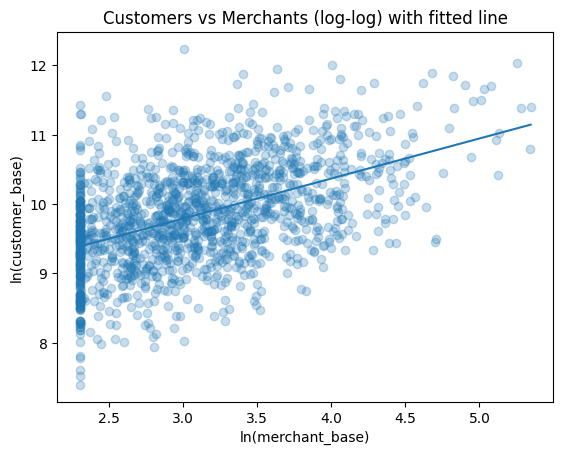

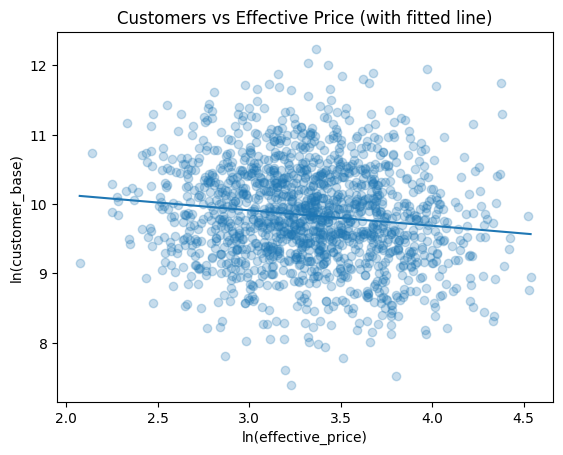

In [8]:
import matplotlib.pyplot as plt

# Customers vs merchants (log-log scatter)
x = reg_df["ln_m"].values          # ln(merchant_base)
y = reg_df["ln_n"].values          # ln(customer_base)

# Fit y = a + b x
b, a = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y, alpha=0.25)
xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, a + b*xx)
plt.xlabel("ln(merchant_base)")
plt.ylabel("ln(customer_base)")
plt.title("Customers vs Merchants (log-log) with fitted line")
plt.show()

# Customers vs effective price (log-log scatter)
x = reg_df["ln_peff"].values
y = reg_df["ln_n"].values

# fit line y = a + b x
b, a = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y, alpha=0.25)
xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, a + b*xx)
plt.xlabel("ln(effective_price)")
plt.ylabel("ln(customer_base)")
plt.title("Customers vs Effective Price (with fitted line)")
plt.show()


### TODO (STUDENT ANSWER): What do you see?[5pts]
Write 2–5 sentences describing what these plots suggest.

Answer:

The log-log plots reveal two key insights.

First, there is a strong positive correlation between the merchant base and the customer base, visually represented by the blue fitted line sloping upward to the right. This relationship strongly suggests cross-side network effects: an increase in merchant variety makes the platform more attractive to consumers, and the tight clustering of data points around the trend line indicates this effect is consistent across market sizes. In log-log terms, the slope of this line directly estimates the elasticity of customer base with respect to merchant base.

Second, the plot of customers vs. effective price shows a clear negative relationship, consistently aligning with the fundamental economic law of demand. This indicates that higher effective prices (the actual amount customers pay after discounts) lead to a smaller active customer base. The slope of this line provides a crucial estimate of price elasticity, highlighting that while price increases may boost short-term margins, they risk shrinking the overall user base and weakening the platform's long-term network feedback loops.

# **5) Estimate network effects (the two key regressions)[15pts]**

Now we estimate the **two-sided system**:

### (A) Customer equation (with network effects)

$$
\ln(n_t)=a + \rho_n \ln(n_{t-1}) + \beta_{nm}\ln(m_t) + \gamma_n \ln(p^{eff}_t) + \varepsilon_t
$$

- $\beta_{nm}$ is the **merchant → customer** network effect (elasticity)

### Variables (things in the data)

- **$n_t$** = `customer_base` in month *t*  
  Think: “How many active customers are on the platform in this market-month?”

- **$n_{t-1}$** = last month’s customer base = `lag_customer_base`  
  This captures persistence: big markets tend to stay big.

- **$m_t$** = `merchant_base` in month *t*  
  How many active merchants are on the platform in this market-month?

- **$p^{eff}_t$** = `effective_price` in month *t*  
  This is the **effective price customers pay after discount**:

  $$
  p^{eff}_t = p_t \cdot (1 - discount_t)
  $$

  In the dataset, `effective_price = avg_deal_price × (1 - avg_deal_discount/100)`.

- **$\ln(\cdot)$** = natural log  
  Taking logs is useful because it turns multiplicative relationships into additive ones, and coefficients become **elasticities** (percent effects).

### Parameters (things we estimate)

- **$a$** = intercept (baseline log customer size when other logged predictors are 0)  
  It mainly soaks up the average level of customers across the sample.

- **$\rho_n$** = customer persistence / “retention-like” parameter  
  Interpretation: if $\rho_n$ is large (close to 1), customer base is **highly persistent** month to month.

  Rough intuition:  
  - higher $\rho_n$ → customers stick around → slower decay after shocks  
  - lower $\rho_n$ → more churn / faster mean reversion

- **$\beta_{nm}$** = **merchant → customer network effect** (elasticity)  
  Because everything is in logs, it’s interpreted as:

  > If merchants increase by **1%**, customers are predicted to increase by about **$\beta_{nm}$%**,  
  holding last month’s customers and effective price constant.

  Why this makes sense: more merchants → more variety/availability → platform more attractive to customers.

- **$\gamma_n$** = effective-price sensitivity (elasticity)  
  Interpretation:

  > If effective price increases by **1%**, customers change by about **$\gamma_n$%**.

  We typically expect $\gamma_n < 0$: higher prices reduce customer participation.

### Error term

- **$\varepsilon_t$** = unobserved factors affecting customers in that month/market  
  Examples: local events, competition, seasonality we didn’t model, randomness.

### (B) Merchant equation (with network effects)

$$
\ln(m_t)=b + \rho_{m1}\ln(m_{t-1}) + \rho_{m2}\ln(m_{t-2}) + \beta_{mn}\ln(n_t) + \gamma_m \ln(p_t) + u_t
$$

- $\beta_{mn}$ is the **customer → merchant** network effect (elasticity)

### Variables (things in the data)

- **$m_t$** = `merchant_base` in month *t*  
  Active merchants in this market-month.

- **$m_{t-1}$** = `lag_merchant_base`  
  Last month’s merchant base.

- **$m_{t-2}$** = `lag2_merchant_base`  
  Two months ago merchant base.  
  This adds extra flexibility in merchant dynamics (merchants may adjust more slowly).

- **$n_t$** = `customer_base` in month *t*  
  Current customer base (how big the demand side is right now).

- **$p_t$** = `avg_deal_price`  
  The “list” or headline deal price before discount.

### Parameters (things we estimate)

- **$b$** = intercept for merchants  
  Baseline log merchant level.

- **$\rho_{m1}$, $\rho_{m2}$** = merchant persistence / inertia parameters  
  Merchants may onboard/offboard more slowly than customers.  
  Positive values mean merchant numbers depend strongly on past merchant levels.

- **$\beta_{mn}$** = **customer → merchant network effect** (elasticity)  
  Interpretation:

  > If customers increase by **1%**, merchants are predicted to increase by about **$\beta_{mn}$%**,  
  holding merchant lags and deal price constant.

  Why: larger customer base makes the platform more attractive for merchants (more sales potential).

- **$\gamma_m$** = deal-price effect on merchant participation (elasticity)  
  Interpretation:

  > If the average deal price increases by **1%**, merchants change by about **$\gamma_m$%**.

  Sign could be positive or negative depending on the story:
  - positive: higher priced deals → higher merchant revenue → more merchants join
  - negative: higher prices reduce demand → fewer merchants see value

### Error term

- **$u_t$** = unobserved factors affecting merchants in that month/market  
  Examples: merchant acquisition campaigns, local regulatory changes, shocks.

We’ll use robust standard errors (HC3).


In [9]:
import statsmodels.formula.api as smf

# TODO (STUDENT): Run the customer regression (with network effects)[5pts]
# ln_n ~ ln_lag_n + ln_m + ln_peff
model_nfx_n = smf.ols("ln_n ~ ln_lag_n + ln_m + ln_peff", data=reg_df).fit(cov_type='HC3')

# TODO (STUDENT): Run the merchant regression (with network effects)[5pts]
# ln_m ~ ln_lag_m + ln_lag2_m + ln_n + ln_p
model_nfx_m = smf.ols("ln_m ~ ln_lag_m + ln_lag2_m + ln_n + ln_p", data=reg_df).fit(cov_type='HC3')

print("Customer equation (with network effects):")
print(model_nfx_n.summary().tables[1])

print("\nMerchant equation (with network effects):")
print(model_nfx_m.summary().tables[1])

Customer equation (with network effects):
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.7518      0.249     27.080      0.000       6.263       7.240
ln_lag_n       0.2399      0.023     10.269      0.000       0.194       0.286
ln_m           0.4705      0.027     17.122      0.000       0.417       0.524
ln_peff       -0.2188      0.037     -5.995      0.000      -0.290      -0.147

Merchant equation (with network effects):
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4236      0.199     -7.155      0.000      -1.814      -1.034
ln_lag_m       0.4862      0.025     19.690      0.000       0.438       0.535
ln_lag2_m      0.0792      0.022      3.536      0.000       0.035       0.123
ln_n           0.2687      0.016     16.922   

## Extract the key coefficients

We care most about:
- $\hat\beta_{nm}$: coefficient on `ln_m` in the customer equation  
- $\hat\beta_{mn}$: coefficient on `ln_n` in the merchant equation  

Also useful:
- $\hat\rho_n$: persistence of customers (retention-ish)
- $\hat\rho_{m1}, \hat\rho_{m2}$: persistence of merchants
- $\hat\gamma_n$: price sensitivity (should be negative)


In [10]:
beta_nm = float(model_nfx_n.params["ln_m"])
beta_mn = float(model_nfx_m.params["ln_n"])

rho_n   = float(model_nfx_n.params["ln_lag_n"])
rho_m1  = float(model_nfx_m.params["ln_lag_m"])
rho_m2  = float(model_nfx_m.params["ln_lag2_m"])

gamma_n = float(model_nfx_n.params["ln_peff"])
gamma_m = float(model_nfx_m.params["ln_p"])

coef_tbl = pd.DataFrame({
    "parameter": [
        "beta_nm (m→n)",
        "beta_mn (n→m)",
        "rho_n",
        "rho_m1",
        "rho_m2",
        "gamma_n (effective price → n)",
        "gamma_m (deal price → m)"
    ],
    "estimate": [beta_nm, beta_mn, rho_n, rho_m1, rho_m2, gamma_n, gamma_m]
})

coef_tbl

,parameter,estimate
0,beta_nm (m→n),0.470465
1,beta_mn (n→m),0.268737
2,rho_n,0.239870
3,rho_m1,0.486227
4,rho_m2,0.079194
5,gamma_n (effective price → n),-0.218817
6,gamma_m (deal price → m),0.019465


### Quick “sanity checks” (expected signs)

In a platform like this, we typically expect:
- $\beta_{nm} > 0$ (more merchants attracts more customers)
- $\beta_{mn} > 0$ (more customers attracts more merchants)
- $\gamma_n < 0$ (higher effective price reduces customer base)


### TODO (STUDENT ANSWER): Interpret the network effects (3–8 sentences)[5pts]

1. What does $\hat\beta_{nm}$ mean in plain English?[2pts]
2. What does $\hat\beta_{mn}$ mean in plain English?[2pts]
3. Why do these imply “two-sided network effects”?[1pts]




#**6) Compute CLV (no network effects) and CLV2 (with network effects)[30pts]**

The teaching note describes two-sided platform profit as:

$$
\Pi = p_1(q_1 + e_{21}q_2) + p_2(q_2 + e_{12}q_1),
$$

where $e_{12}$ and $e_{21}$ measure cross-side attraction (network effects).

Then it gives lifetime value of a side-1 customer:

$$
LTV_1 = \frac{p_1^*}{r_1} + \frac{e_{12}p_2^*}{r_2},
$$

where $r_1, r_2$ are churn rates (expected lifetime is about $1/r$).

### Our plan (what YOU will compute)
We will compute this in two stages:

**Stage A — Pure CLV (ignore network effects):**
1) Estimate **per-period marginal profit** for each side:
- $p_C$ = marginal profit per customer (holding merchants fixed)
- $p_M$ = marginal profit per merchant (holding customers fixed)

2) Estimate **churn rates**:
- $r_C$ = customer churn per month
- $r_M$ = merchant churn per month

3) Compute **pure CLV**:
$$
CLV_C = \frac{p_C}{r_C},
\qquad
CLV_M = \frac{p_M}{r_M}
$$

**Stage B — CLV2 (add network effects):**

4) Estimate cross-side network effects:
- $e_{12}$ = customers → merchants
- $e_{21}$ = merchants → customers

5) Compute **CLV2**:
$$
CLV2_C = \frac{p_C}{r_C} + e_{12}\frac{p_M}{r_M}
$$

$$
CLV2_M = \frac{p_M}{r_M} + e_{21}\frac{p_C}{r_C}
$$

You will fill in the calculations in the TODO code cells below.


In [ ]:
# Setup
import statsmodels.api as sm

df = pd.read_csv(DATA_PATH)
df = df.sort_values(["market_id", "month"]).reset_index(drop=True)

# Representative baseline state (use median row values, month ~ middle)
rep = df[df["month"] == 6].median(numeric_only=True)

n0 = float(rep["customer_base"])
m0 = float(rep["merchant_base"])
gb0 = float(rep["avg_gross_billings"])
disc0 = float(rep["avg_deal_discount"])   # percent (0..100)

print(f"Baseline state: n0={n0:.2f}, m0={m0:.2f}, gb0={gb0:,.2f}, disc0={disc0:.2f}%")

Baseline state: n0=18046.36, m0=20.35, gb0=268,908.49, disc0=59.12%


### Stage A1 — Per-period marginal profit ($p_C$, $p_M$)

We approximate marginal profit using a small **finite-difference** shock:
- set $\epsilon = 0.01$ (a +1% change)

We compute profit at baseline $(n0,m0)$ and then:
- increase customers to $(1+\epsilon)n0$ holding merchants fixed → get $p_C$
- increase merchants to $(1+\epsilon)m0$ holding customers fixed → get $p_M$

Finite-difference formulas:
$$
p_C \approx \frac{\Pi((1+\epsilon)n_0, m_0)-\Pi(n_0,m_0)}{\epsilon n_0}
$$

$$
p_M \approx \frac{\Pi(n_0,(1+\epsilon)m_0)-\Pi(n_0,m_0)}{\epsilon m_0}
$$

✅ TODO: Implement these calculations.


In [ ]:
def take_rate_from_discount(disc_percent: float) -> float:
    disc = disc_percent / 100.0
    tr = 0.50 * (1 - 1.15*(disc - 0.55))
    return float(clip(tr, 0.18, 0.55))

def profit_from_state(gb, disc_percent, capture=0.85):
    tr = take_rate_from_discount(disc_percent)
    revenue = capture * tr * gb
    profit = 0.70 * revenue
    return profit

def gb_counterfactual(n_new, m_new, n_base, m_base, gb_base, exp_n=0.55, exp_m=0.35):
    return gb_base * (n_new/n_base)**exp_n * (m_new/m_base)**exp_m

eps = 0.01

# Baseline profit
pi0 = profit_from_state(gb0, disc0)

# +1% customers (merchants fixed)
n1 = (1 + eps) * n0
gb_n1 = gb_counterfactual(n1, m0, n0, m0, gb0)
pi_n1 = profit_from_state(gb_n1, disc0)

# +1% merchants (customers fixed)
m1 = (1 + eps) * m0
gb_m1 = gb_counterfactual(n0, m1, n0, m0, gb0)
pi_m1 = profit_from_state(gb_m1, disc0)

# TODO (STUDENT): compute marginal profit per customer and per merchant[5pts]
p_C = (pi_n1 - pi0) / (eps * n0)
p_M = (pi_m1 - pi0) / (eps * m0)

print(f"p_C (profit per customer per month) = {p_C:.6f}")
print(f"p_M (profit per merchant per month) = {p_M:.6f}")

p_C (profit per customer per month) = 2.317400
p_M (profit per merchant per month) = 1306.756053


### Stage A2 — Estimate churn rates ($r_C$, $r_M$)

The teaching note uses churn rate $r$ and the idea that expected lifetime is about $1/r$.

We will estimate **monthly retention** using a simple AR(1) model in levels:

$$
n_t \approx a + \phi_C n_{t-1} + \varepsilon_t
$$

Interpretation:
- $\phi_C$ is the “carry-over” / retention factor per month
- monthly churn is approximated by:
$$
r_C \approx 1 - \phi_C
$$

We do the same for merchants:
$$
m_t \approx a + \phi_M m_{t-1} + \varepsilon_t,
\qquad
r_M \approx 1 - \phi_M
$$

✅ TODO: Estimate $\phi_C$ and $\phi_M$ and compute $r_C$ and $r_M$.


In [ ]:
reg_churn = df.dropna(subset=["lag_customer_base","lag_merchant_base"]).copy()

# Customer churn regression in levels
Xc = sm.add_constant(reg_churn["lag_customer_base"])
yc = reg_churn["customer_base"]
mod_c = sm.OLS(yc, Xc).fit()

# Merchant churn regression in levels
Xm = sm.add_constant(reg_churn["lag_merchant_base"])
ym = reg_churn["merchant_base"]
mod_m = sm.OLS(ym, Xm).fit()

# TODO (STUDENT): extract phi and compute churn[5pts]
phi_C = mod_c.params["lag_customer_base"]
phi_M = mod_m.params["lag_merchant_base"]

r_C = 1 - phi_C
r_M = 1 - phi_M

print("phi_C =", phi_C, "=> r_C =", r_C)
print("phi_M =", phi_M, "=> r_M =", r_M)


### Stage A3 — Compute PURE CLV (no network effects)

Now compute:

$$
CLV_C = \frac{p_C}{r_C},
\qquad
CLV_M = \frac{p_M}{r_M}
$$

✅ TODO: Calculate CLV_C and CLV_M.


In [ ]:
# TODO (STUDENT): compute pure CLV[5pts]
CLV_C = # TODO (STUDENT)
CLV_M = # TODO (STUDENT)

print(f"CLV_C (pure, no network) = {CLV_C:,.2f}")
print(f"CLV_M (pure, no network) = {CLV_M:,.2f}")

### Stage B1 — Estimate network effects ($e_{12}$ and $e_{21}$)

The teaching note defines:
- $e_{21}$ as “how much side 2 attracts side 1”
- $e_{12}$ as “how much side 1 attracts side 2”

We estimate **cross-side elasticities** using log regressions:

Customer side:
$$
\log(n_t) = \dots + \beta_{NM}\log(m_t) + \dots
$$
Merchant side:
$$
\log(m_t) = \dots + \beta_{MN}\log(n_t) + \dots
$$

To convert elasticity into “users attracted per 1 user” at the baseline state:

$$
e_{12} \approx \beta_{MN}\frac{m_0}{n_0}
\qquad
e_{21} \approx \beta_{NM}\frac{n_0}{m_0}
$$

✅ TODO: Fit the two log regressions, extract $\beta_{NM}$ and $\beta_{MN}$(we've already done that in section 5 estimate the network effect!), then compute $e_{12}$ and $e_{21}$.


In [ ]:
# TODO (STUDENT): convert to "users per user" at baseline[5pts]
e12 = # TODO (STUDENT)
e21 = # TODO (STUDENT)

print("beta_NM (m->n elasticity) =", beta_nm)
print("beta_MN (n->m elasticity) =", beta_mn)
print("e12 (customers -> merchants) =", e12)
print("e21 (merchants -> customers) =", e21)


### Stage B2 — Compute CLV2 (with network effects)

Now plug into the teaching-note structure:

$$
CLV2_C = \frac{p_C}{r_C} + e_{12}\frac{p_M}{r_M}
$$

$$
CLV2_M = \frac{p_M}{r_M} + e_{21}\frac{p_C}{r_C}
$$

✅ TODO: Compute CLV2_C and CLV2_M. Then answer:
1) Are CLV2 values larger than pure CLV? Why?
2) Interpret $e_{12}$ and $e_{21}$ in plain English.


In [ ]:
# TODO (STUDENT): compute CLV2[5pts]
CLV2_C = # TODO (STUDENT)
CLV2_M = # TODO (STUDENT)

print(f"CLV2_C (with network) = {CLV2_C:,.2f}")
print(f"CLV2_M (with network) = {CLV2_M:,.2f}")

pd.DataFrame({
    "metric": ["CLV_C", "CLV_M", "CLV2_C", "CLV2_M"],
    "value":  [CLV_C,  CLV_M,  CLV2_C,  CLV2_M]
})

### TODO (STUDENT ANSWER):Interprete the result[5pts]




# **7) Where should we spend $100,000? (Policy lever comparison)**

Now you will use your estimated CLV / CLV2 logic to compare four growth levers:

1) **CAC / Marketing**: spend `$100,000` to acquire customers at CAC = `$20`  
2) **Discounts**: increase discount by +5 percentage points (e.g., 59% → 64%)  
3) **Network design**: invest to strengthen cross-side network effects  
4) **Reduce churn**: invest to improve retention (reduce churn) and reduce leakage (“capture” improves)

### What you will compute
For each lever, compute **PV profit**:

$$
PV = \sum_{t=0}^{T-1} \delta^t \pi_t
$$

Then compute incremental PV relative to baseline:

$$
\Delta PV = PV^{lever} - PV^{baseline}
$$

Finally, recommend the best use of $100,000$.

---

### Lever definitions

- **Baseline (none):** capture = 0.85  
- **Network design:** increase network-effect elasticities  
  - $\beta_{NM} \leftarrow \beta_{NM} + 0.08$  
  - $\beta_{MN} \leftarrow \beta_{MN} + 0.06$  
  - capture = 0.88
- **Reduce churn:** increase persistence (retention)  
  - customer persistence $\rho_C \leftarrow \rho_C + 0.08$  
  - merchant persistence $\rho_{M1} \leftarrow \rho_{M1} + 0.08$  
  - capture = 0.92
- **Discount +5pp:** discount percent increases by 5 points  
  - this reduces take rate and therefore profit per dollar of billings
- **CAC:** add customers at $t=0$  
  - customers added = $100,000 / 20 = 5,000$  
  - we subtract $100,000 from PV to reflect marketing cost

> Note: These are stylized assumptions for teaching purposes.


In [ ]:
# We'll reuse the same baseline profit mechanics from the CLV section.
# TODO (STUDENT): Here we simulate forward and compute PV profit for each lever.[10 pts]

DELTA = 0.97
T = 36

def pv(profit_path, delta=DELTA):
    w = delta ** np.arange(len(profit_path))
    return float(np.sum(profit_path * w))

# Build a "baseline simulation engine" for lever comparison.
# We simulate in logs, using the network-effects regressions (the CLV2 system),
# because policy levers should affect the full two-sided dynamics.

# Extract baseline coefficients from the network-effect (CLV2) regressions
a_n = float(model_nfx_n.params["Intercept"])         # customer equation intercept
rho_n = float(model_nfx_n.params["ln_lag_n"])   # customer persistence
beta_nm = float(model_nfx_n.params["ln_m"])     # merchants -> customers elasticity
gamma_n = float(model_nfx_n.params["ln_peff"]) # effective price effect

a_m = float(model_nfx_m.params["Intercept"])         # merchant equation intercept
rho_m1 = float(model_nfx_m.params["ln_lag_m"])  # merchant persistence lag1
rho_m2 = float(model_nfx_m.params["ln_lag2_m"]) # merchant persistence lag2
beta_mn = float(model_nfx_m.params["ln_n"])     # customers -> merchants elasticity
gamma_m = float(model_nfx_m.params["ln_p"])     # deal price effect

# Baseline state from earlier section
# n0, m0, gb0, disc0 already defined (median representative state)
p0 = float(rep["avg_deal_price"])
peff0 = float(max(p0 * (1 - disc0/100.0), 1e-8))

def simulate_lever(lever="none", spend=100000, cac=20, discount_pp=5):
    """
    Returns: profit path (length T) under lever
    """
    # TODO (STUDENT)


    return np.array(prof), disc

# Baseline PV
prof_base, _ = simulate_lever("none")
pv_base = pv(prof_base)

pv_base

### ✅ TODO (STUDENT): Compute PV profit for each lever and rank them[5pts]

Compute PV profit and incremental PV relative to baseline for:

- `none`
- `network_design`
- `reduce_churn`
- `cac`
- `discount`

For CAC, subtract the $100,000 spend from PV.

Then rank by incremental PV and recommend the best use of $100,000.


In [ ]:
# TODO (STUDENT): compute PV under each lever[5pts]
results = []

# none
prof_none, _ = simulate_lever("none")
pv_none = pv(prof_none)
results.append(("none", pv_none, pv_none - pv_base))

# network design
prof_nd, _ = # TODO (STUDENT)
pv_nd = # TODO (STUDENT)
results.append(("network_design", pv_nd, pv_nd - pv_base))

# reduce churn
prof_rc, _ = # TODO (STUDENT)
pv_rc = # TODO (STUDENT)
results.append(("reduce_churn", pv_rc, pv_rc - pv_base))

# CAC (subtract spend)
prof_cac, _ = # TODO (STUDENT)
pv_cac = # TODO (STUDENT)
results.append(("cac", pv_cac, pv_cac - pv_base))

# discount
prof_disc, disc_used = # TODO (STUDENT)
pv_disc = # TODO (STUDENT)
results.append((f"discount(+5pp to {disc_used:.1f}%)", pv_disc, pv_disc - pv_base))

lever_tbl = pd.DataFrame(results, columns=["lever", "PV_profit", "Incremental_PV"])
lever_tbl = lever_tbl.sort_values("Incremental_PV", ascending=False).reset_index(drop=True)
lever_tbl


### TODO (STUDENT ANSWER): Recommendation (short memo)[5pts]

1) Which lever gives the highest incremental PV profit?  
2) Why does the model favor that lever (connect to CLV vs CLV2 logic)?  
3) Which lever is worst and why?

# **8) Customer Equity Calculation[10pts]**

In marketing, **Customer Equity** is defined as:

$$
CE \;=\; N \times \overline{CLV2}_C
$$

where:
- $N$ is the **total number of customers** (customer base) at the evaluation point,
- $\overline{CLV2}_C$ is the **average customer lifetime value accounting for network effects** (CLV2).

Similarly, **Merchant Equity** is:

$$
ME \;=\; M \times \overline{MLV2}_M
$$

where:
- $M$ is the **total number of merchants** (merchant base),
- $\overline{MLV2}_M$ is the **average merchant lifetime value accounting for network effects** (MLV2).

Therefore, the **total firm value** (two-sided) is:

$$
V_{\text{firm}} \;=\; N\overline{CLV2}_C \;+\; M\overline{MLV2}_M
$$

✅ **TODO (STUDENT) Compare baseline vs. your recommended policy.[10pts]**

1) Compute $N$ and $M$ (aggregate customer base and merchant base).  
2) Multiply by the corresponding average CLV2/MLV2 to obtain:
- Customer Equity: $CE$
- Merchant Equity: $ME$
- Firm Value: $V_{\text{firm}}$

3) Report and interprete the changes:
$$
\Delta CE,\ \Delta ME,\ \Delta V_{\text{firm}}
$$

In [ ]:
# TODO (STUDENT): vibe coding to compute


## TODO (STUDENT ANSWER): Interpretation